# Lab 4: K-Means and Hierarchical Clustering

This notebook provides a complete and structured implementation of unsupervised clustering algorithms on the Iris dataset:
1. **Exploratory Data Analysis (EDA)**: Feature distributions, correlation heatmap, and bivariate separation.
2. **Model Training & Diagnostics**: Elbow Method curve (Inertia vs. $k$), Silhouette score optimization curve, and Hierarchical Clustering Dendrogram.
3. **Model Training & Centroid Visualization**: K-Means and Hierarchical Agglomerative clustering with prominently marked cluster centroids.
4. **Cluster Alignment**: Hungarian algorithm (`linear_sum_assignment`) to match cluster indices with ground truth classes.
5. **Performance & Error Metrics**: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index, MAE, MSE, and RMSE.
6. **Visualizations**: 2D feature scatter plots, 2D PCA projections, metric comparison bar charts, and confusion matrix heatmaps.

## 1. Imports and Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import (
    confusion_matrix, silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, mean_absolute_error, mean_squared_error
)

# Set visual style
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.autolayout"] = True
print("All required libraries imported successfully.")

All required libraries imported successfully.


## 2. Dataset Loading & Minimal Preprocessing

In [12]:
# Load the benchmark Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = [iris.target_names[i] for i in iris.target]

X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Minimal necessary preprocessing: feature standardization for distance-based clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset Shape: {X_scaled.shape}")
print(f"Target Classes: {target_names.tolist()} (Counts: {np.bincount(y).tolist()})")
df.head()

Dataset Shape: (150, 4)
Target Classes: ['setosa', 'versicolor', 'virginica'] (Counts: [50, 50, 50])


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. Exploratory Data Analysis (EDA)
Visualizing feature distributions, correlations, and natural class separation in the raw data.

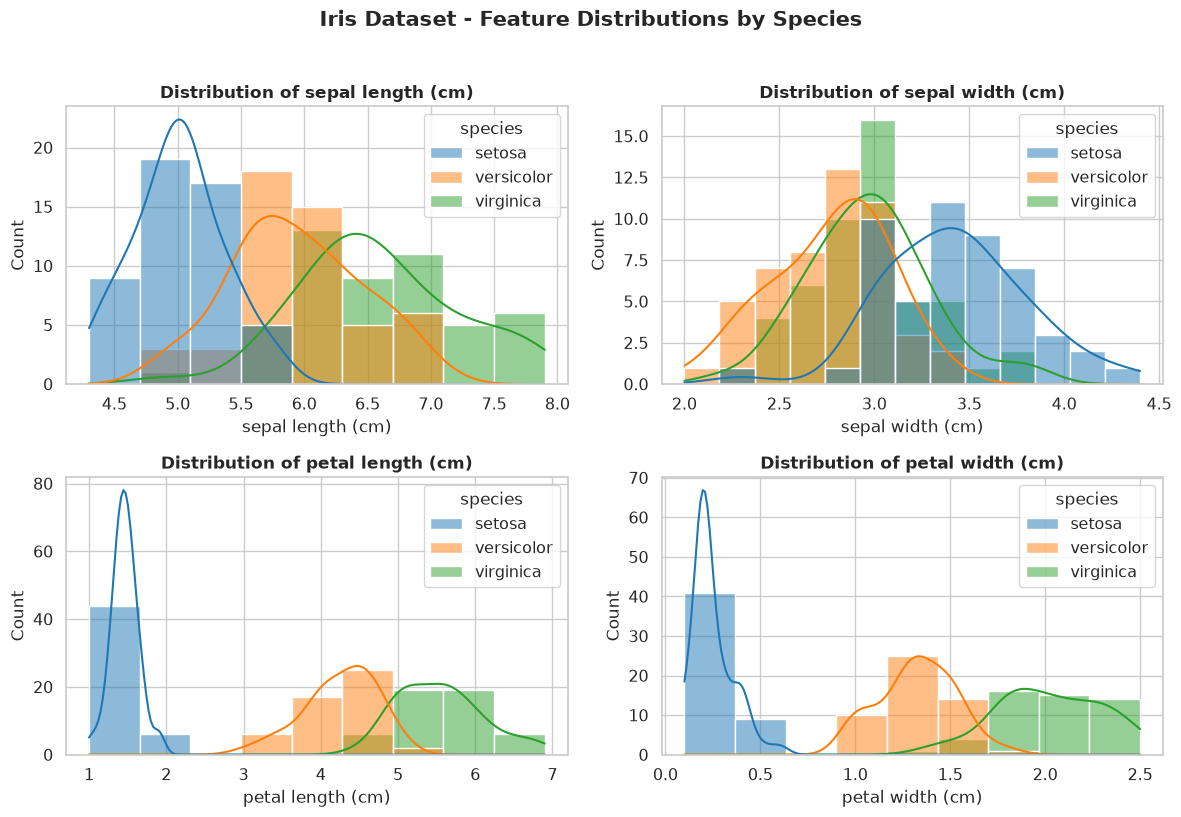

In [13]:
# 3.1 Feature Distributions (Histograms + KDE)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(feature_names):
    sns.histplot(data=df, x=col, hue="species", kde=True, ax=axes[i], palette="tab10", alpha=0.5)
    axes[i].set_title(f"Distribution of {col}", fontweight="bold")

plt.suptitle("Iris Dataset - Feature Distributions by Species", fontsize=15, fontweight="bold", y=1.02)
plt.show()

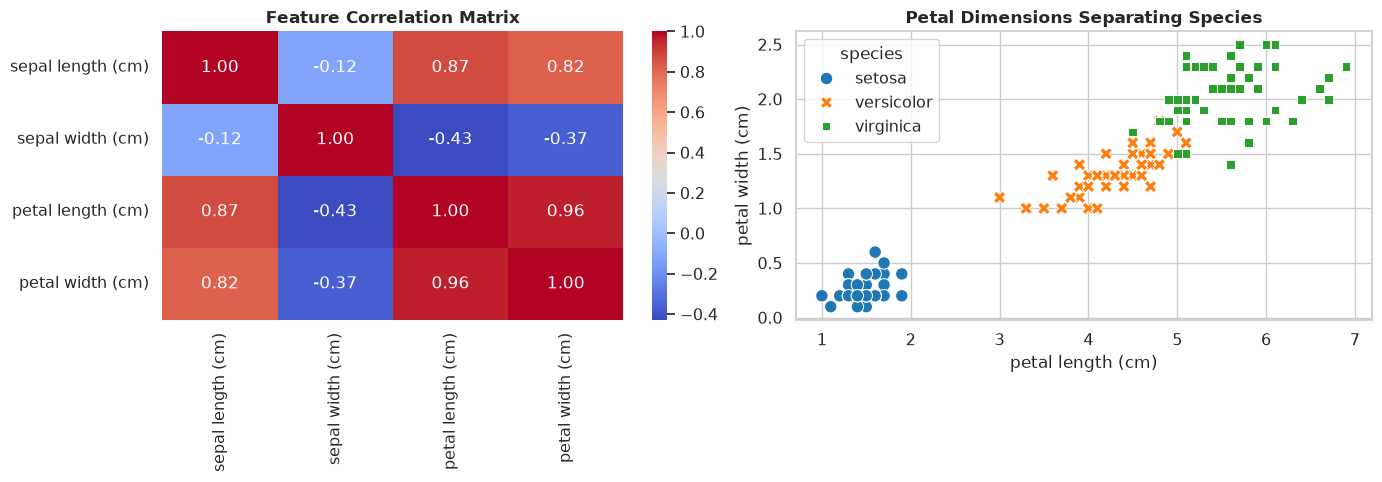

In [14]:
# 3.2 Correlation Heatmap and Bivariate Scatter Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation Heatmap
numeric_df = df[feature_names]
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", cbar=True, ax=axes[0])
axes[0].set_title("Feature Correlation Matrix", fontweight="bold")

# Petal Length vs Petal Width Scatter Plot
sns.scatterplot(
    data=df, x="petal length (cm)", y="petal width (cm)", 
    hue="species", style="species", s=80, palette="tab10", ax=axes[1]
)
axes[1].set_title("Petal Dimensions Separating Species", fontweight="bold")

plt.show()

## 4. Proper Model Training & Optimization Curves
Here we perform hyperparameter sweeps to evaluate clustering performance across candidate cluster counts ($k=1 \dots 10$). We plot the **Elbow Method (Inertia vs. $k$)** and the **Silhouette Score curve** to validate that $k=3$ is indeed the optimal choice.

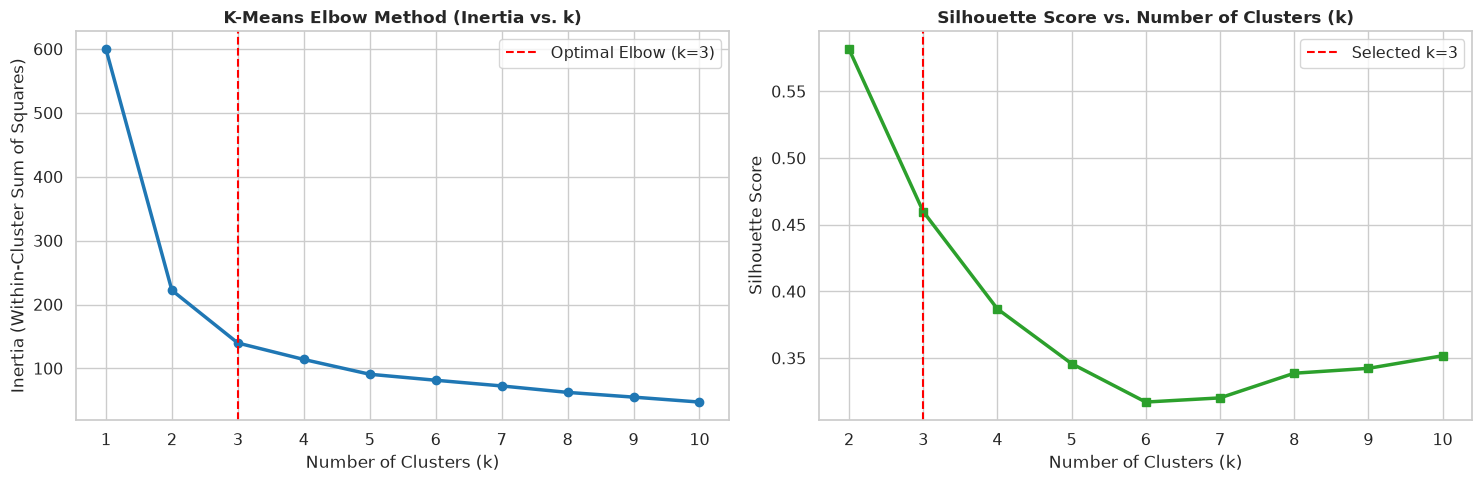

In [15]:
# Hyperparameter sweep for K-Means
k_range = range(1, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X_scaled, km.labels_))
    else:
        silhouette_scores.append(None)

# Plot Training Diagnostic Curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Elbow Method (Inertia vs k)
axes[0].plot(list(k_range), inertias, marker="o", linewidth=2.5, color="#1f77b4")
axes[0].axvline(x=3, color="red", linestyle="--", label="Optimal Elbow (k=3)")
axes[0].set_title("K-Means Elbow Method (Inertia vs. k)", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].set_xticks(list(k_range))
axes[0].legend()

# 2. Silhouette Score vs k
axes[1].plot(list(range(2, 11)), silhouette_scores[1:], marker="s", linewidth=2.5, color="#2ca02c")
axes[1].axvline(x=3, color="red", linestyle="--", label="Selected k=3")
axes[1].set_title("Silhouette Score vs. Number of Clusters (k)", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_xticks(list(range(2, 11)))
axes[1].legend()

plt.show()

### Hierarchical Clustering Dendrogram
Visualizing sample hierarchy using Ward's minimum variance linkage.

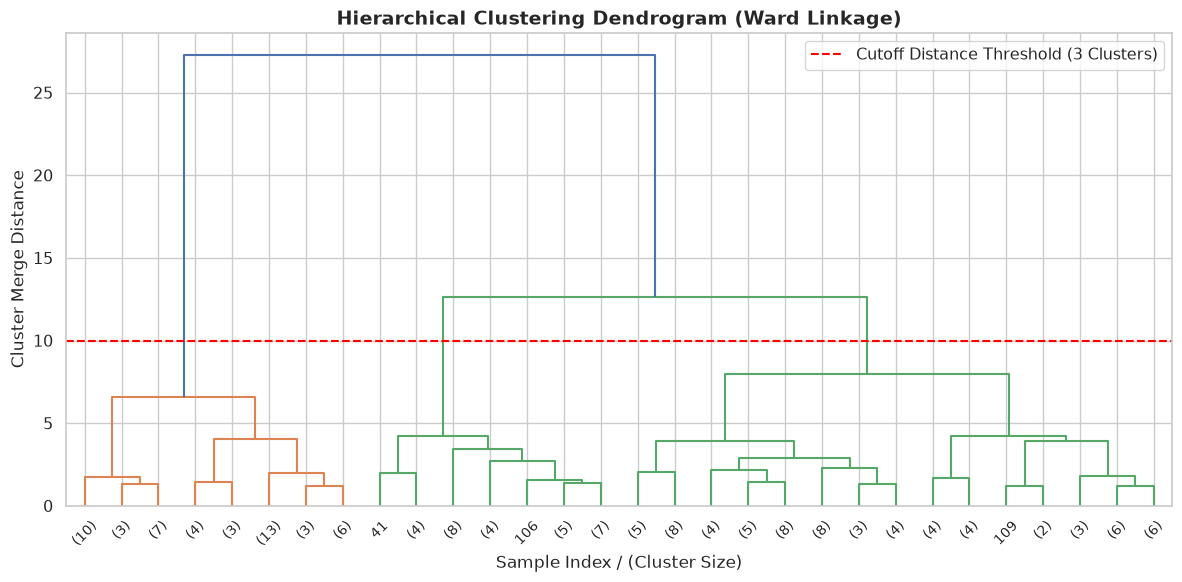

In [16]:
# Compute Ward linkage matrix
linkage_matrix = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, truncate_mode="lastp", p=30, leaf_rotation=45, leaf_font_size=10)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize=14, fontweight="bold")
plt.xlabel("Sample Index / (Cluster Size)")
plt.ylabel("Cluster Merge Distance")
plt.axhline(y=10, color="red", linestyle="--", label="Cutoff Distance Threshold (3 Clusters)")
plt.legend(loc="upper right")
plt.show()

## 5. Model Fitting & Optimal Cluster Alignment
Fitting K-Means ($k=3$) and Agglomerative Hierarchical Clustering ($k=3$), then mapping unsupervised cluster indices to true class labels via the Hungarian algorithm (`linear_sum_assignment`).

In [17]:
# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Fit Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
hier_labels = hierarchical.fit_predict(X_scaled)

# Optimal Hungarian Alignment to Ground Truth Labels
def align_clusters(y_true, cluster_labels):
    cm = confusion_matrix(y_true, cluster_labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {cluster: true_lbl for true_lbl, cluster in zip(row_ind, col_ind)}
    return np.array([mapping[c] for c in cluster_labels])

kmeans_aligned = align_clusters(y, kmeans_labels)
hier_aligned = align_clusters(y, hier_labels)

print("Models fitted and cluster labels aligned successfully.")
print(f"K-Means cluster counts: {np.bincount(kmeans_labels).tolist()}")
print(f"Hierarchical cluster counts: {np.bincount(hier_labels).tolist()}")

Models fitted and cluster labels aligned successfully.
K-Means cluster counts: [53, 50, 47]
Hierarchical cluster counts: [71, 49, 30]


## 6. Cluster Visualizations with Centroids
### 6.1 2D Feature Space (Petal Length vs. Petal Width) with Centroids

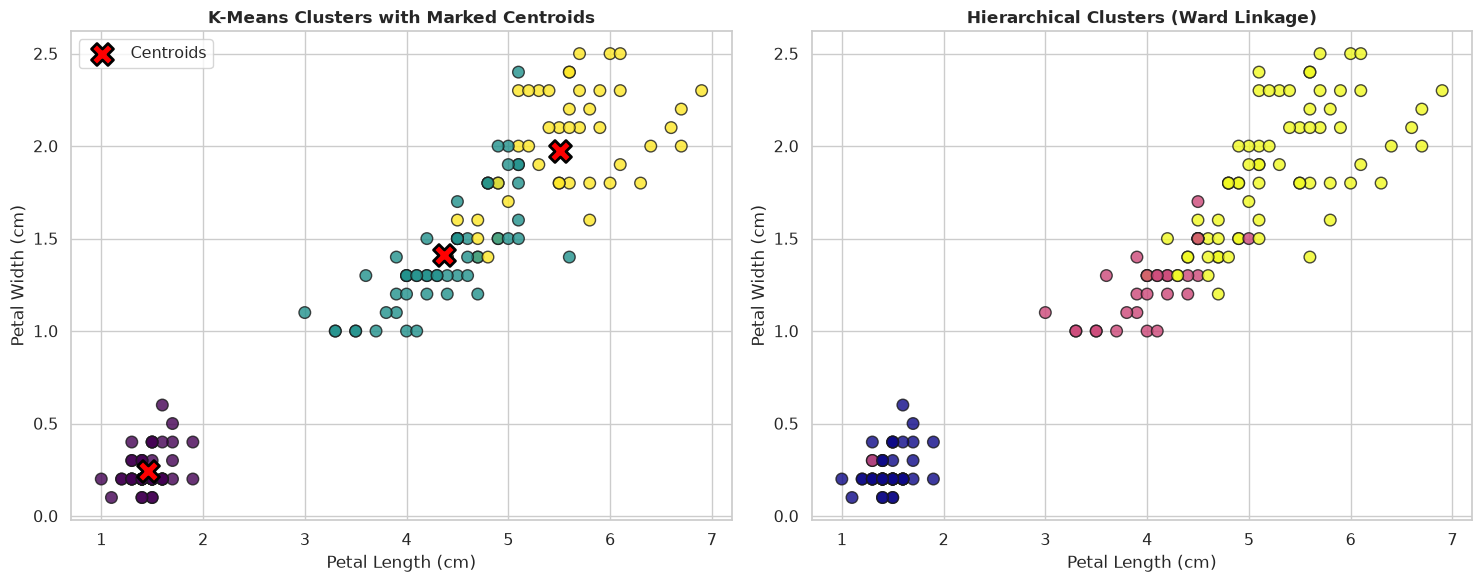

In [18]:
# Inverse transform scaled centroids back to original feature scale for intuitive feature-space plotting
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means Clusters with Centroids
scatter1 = axes[0].scatter(X[:, 2], X[:, 3], c=kmeans_aligned, cmap="viridis", s=70, edgecolor="k", alpha=0.8)
axes[0].scatter(
    centers_original[:, 2], centers_original[:, 3], 
    c="red", marker="X", s=250, edgecolor="black", linewidth=2, label="Centroids"
)
axes[0].set_title("K-Means Clusters with Marked Centroids", fontweight="bold")
axes[0].set_xlabel("Petal Length (cm)")
axes[0].set_ylabel("Petal Width (cm)")
axes[0].legend(loc="upper left")

# Hierarchical Clusters
scatter2 = axes[1].scatter(X[:, 2], X[:, 3], c=hier_aligned, cmap="plasma", s=70, edgecolor="k", alpha=0.8)
axes[1].set_title("Hierarchical Clusters (Ward Linkage)", fontweight="bold")
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")

plt.show()

### 6.2 2D PCA Projections with Transformed Centroids

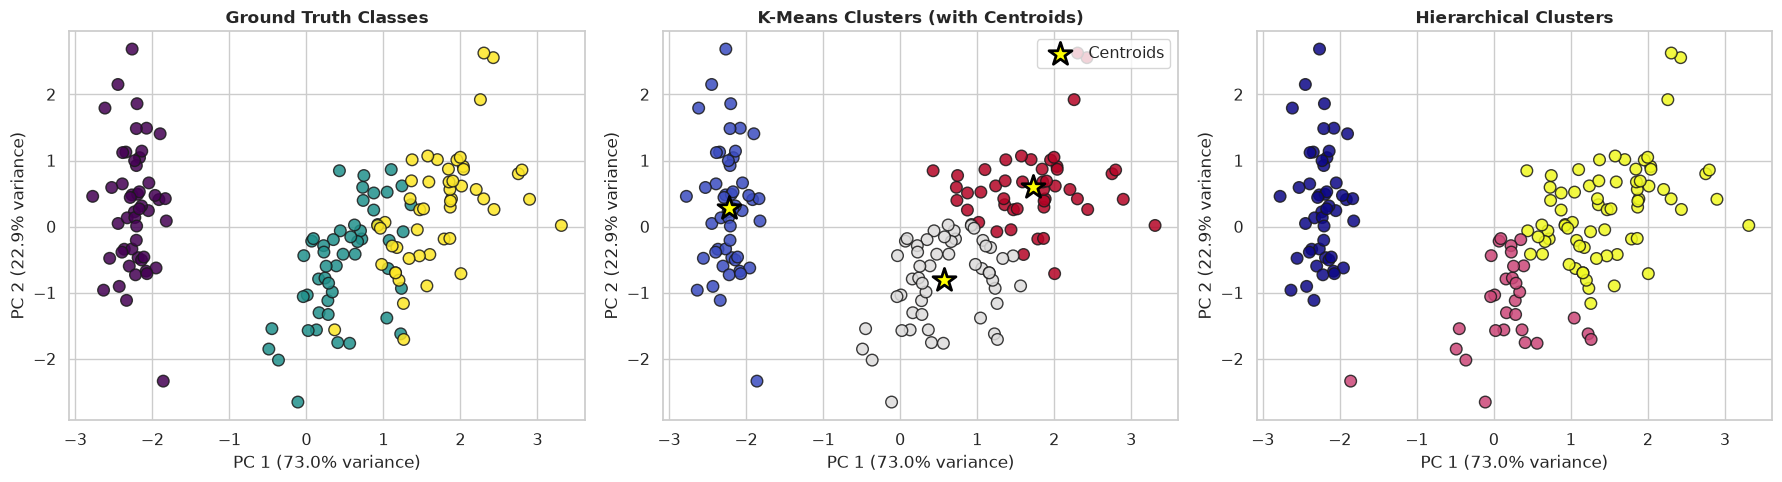

In [19]:
# Project scaled features and K-Means centroids into 2D PCA space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
centers_pca = pca.transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Ground Truth Classes", "K-Means Clusters (with Centroids)", "Hierarchical Clusters"]
labels_list = [y, kmeans_aligned, hier_aligned]
palettes = ["viridis", "coolwarm", "plasma"]

for i, (ax, title, lbls, pal) in enumerate(zip(axes, titles, labels_list, palettes)):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=lbls, cmap=pal, edgecolor="k", s=70, alpha=0.85)
    if i == 1:
        ax.scatter(
            centers_pca[:, 0], centers_pca[:, 1], 
            c="yellow", marker="*", s=300, edgecolor="black", linewidth=2, label="Centroids"
        )
        ax.legend(loc="upper right")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(f"PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")

plt.show()

## 7. Performance & Error Metrics Evaluation

In [20]:
# Compute Unsupervised Metrics and Error Metrics
metrics = {
    "Silhouette Score": [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, hier_labels)
    ],
    "Davies-Bouldin Index": [
        davies_bouldin_score(X_scaled, kmeans_labels),
        davies_bouldin_score(X_scaled, hier_labels)
    ],
    "Calinski-Harabasz Index": [
        calinski_harabasz_score(X_scaled, kmeans_labels),
        calinski_harabasz_score(X_scaled, hier_labels)
    ],
    "MAE": [
        mean_absolute_error(y, kmeans_aligned),
        mean_absolute_error(y, hier_aligned)
    ],
    "MSE": [
        mean_squared_error(y, kmeans_aligned),
        mean_squared_error(y, hier_aligned)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y, kmeans_aligned)),
        np.sqrt(mean_squared_error(y, hier_aligned))
    ]
}

results_df = pd.DataFrame(metrics, index=["K-Means", "Hierarchical"])
results_df.round(4)

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,MAE,MSE,RMSE
K-Means,0.4599,0.8336,241.9044,0.1667,0.1667,0.4082
Hierarchical,0.4467,0.8035,222.7192,0.1733,0.1733,0.4163


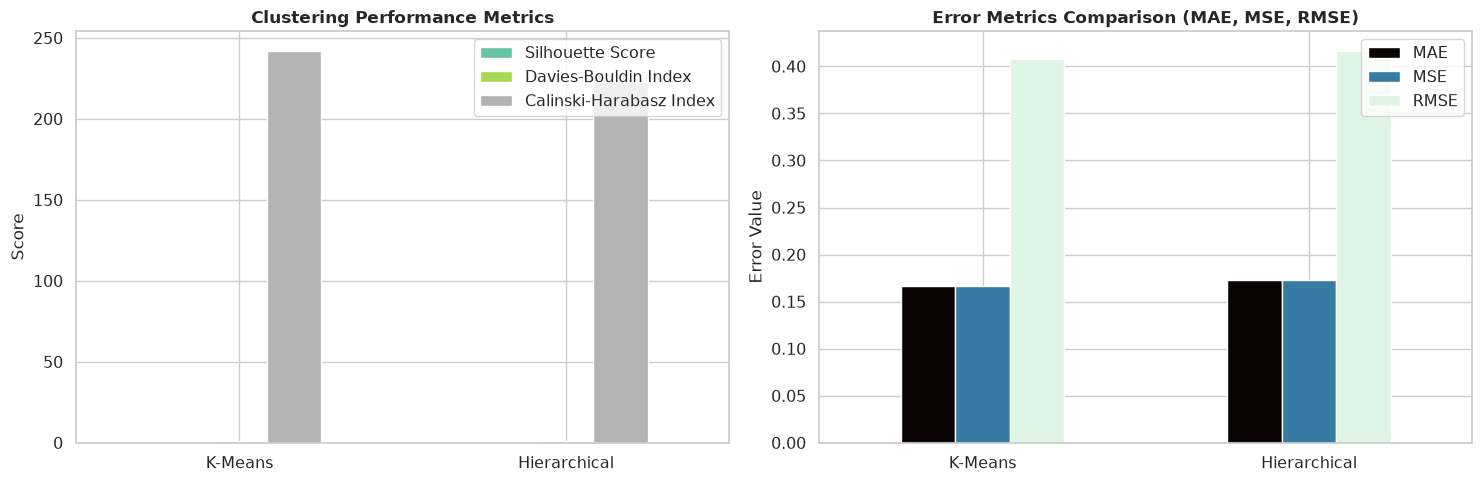

In [21]:
# Plot Evaluation Metrics and Error Metrics Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Clustering Metrics
cluster_cols = ["Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Index"]
results_df[cluster_cols].plot(kind="bar", ax=axes[0], colormap="Set2")
axes[0].set_title("Clustering Performance Metrics", fontweight="bold")
axes[0].set_ylabel("Score")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper right")

# Error Metrics (MAE, MSE, RMSE)
error_cols = ["MAE", "MSE", "RMSE"]
results_df[error_cols].plot(kind="bar", ax=axes[1], colormap="mako")
axes[1].set_title("Error Metrics Comparison (MAE, MSE, RMSE)", fontweight="bold")
axes[1].set_ylabel("Error Value")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(loc="upper right")

plt.show()

## 8. Confusion Matrices

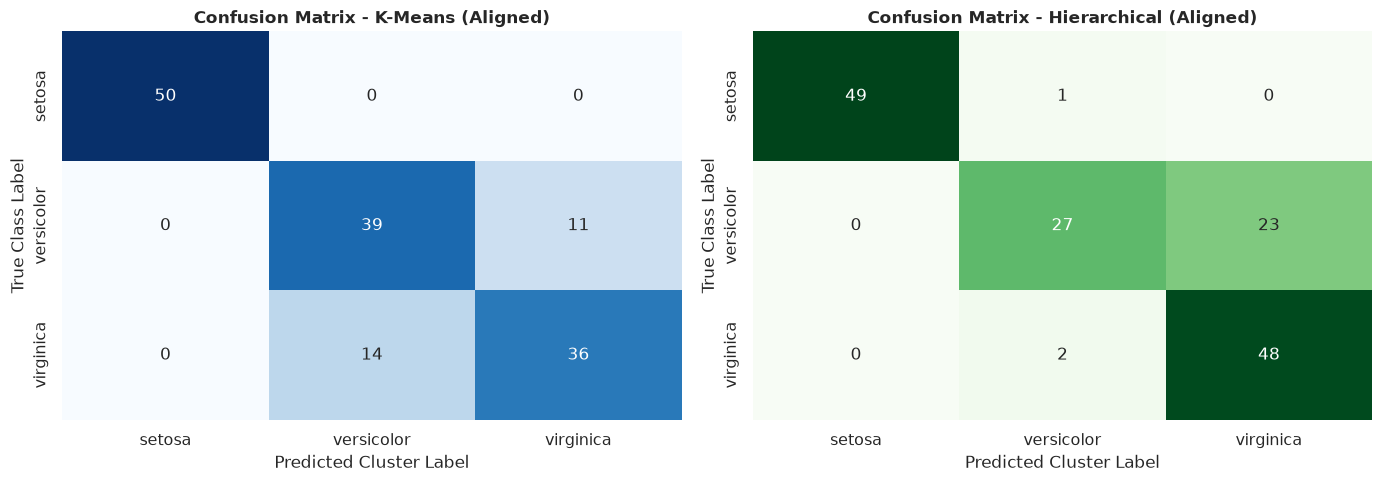

In [22]:
cm_kmeans = confusion_matrix(y, kmeans_aligned)
cm_hier = confusion_matrix(y, hier_aligned)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means Confusion Matrix
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=target_names, yticklabels=target_names)
axes[0].set_title("Confusion Matrix - K-Means (Aligned)", fontweight="bold")
axes[0].set_xlabel("Predicted Cluster Label")
axes[0].set_ylabel("True Class Label")

# Hierarchical Confusion Matrix
sns.heatmap(cm_hier, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[1],
            xticklabels=target_names, yticklabels=target_names)
axes[1].set_title("Confusion Matrix - Hierarchical (Aligned)", fontweight="bold")
axes[1].set_xlabel("Predicted Cluster Label")
axes[1].set_ylabel("True Class Label")

plt.show()